# Module 21 — GRPO & RLVR: The New Wave (DeepSeek-R1 and Beyond)

**Part V · Generation & Alignment · 40–50 min**

---

In January 2025, DeepSeek released **R1-Zero** — a model trained with pure reinforcement learning, no human-written chain-of-thought data, no preference labels, no reward model. And somewhere around step 8,000 of training, something weird started happening in the logs.

The model began writing things like:

> *"Wait. Let me reconsider. If I multiply both sides by 3... no, that's wrong. Let me try again from the top."*

Nobody told it to say "wait". Nobody wrote an example of self-reflection for it to imitate. The reward function didn't care about prose style — it only checked whether the final answer was correct. And yet, under pressure from that reward, the model *spontaneously* invented the habit of second-guessing itself. The DeepSeek paper called it **the "aha moment"**, and it genuinely was one. It was the first unambiguous demonstration that long-horizon reasoning could emerge from pure RL.

The training algorithm behind it is called **GRPO** (Group Relative Policy Optimization), and it fits in about thirty lines of PyTorch. The reward signal is called **RLVR** (Reinforcement Learning with Verifiable Rewards), and it replaces the entire human-labeled preference pipeline with a Python function that returns `True` or `False`.

This module is the story of how these two ideas — together — ate the 2024-era alignment stack.

**What we'll do:**

1. Understand *why* PPO has a critic problem — and what "critic" even means.
2. Derive GRPO as "PPO minus the critic, plus a group baseline". Walk through every symbol.
3. Understand RLVR: why "just check the answer" was the move all along.
4. Train a tiny model from scratch on integer multiplication with GRPO+RLVR. Watch accuracy climb.
5. **Break it on purpose.** Remove the group normalization. Watch it fall apart.
6. Look at a canned R1-Zero-style reflection trace.
7. Meet **DAPO**, the 2025 follow-up that cranked Qwen2.5-32B to 50 on AIME.

Everything runs on CPU in about two minutes.

## 0 · Setup

In [1]:
# !pip install -q torch numpy matplotlib

import math, time, random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch :", torch.__version__)

device: cpu
torch : 2.4.1


In [2]:
# Inherit the Part I palette so this module lives in the same visual world.
PALETTE = {
    "ink":    "#1a1a2e",
    "paper":  "#f7f3e9",
    "rose":   "#e63946",
    "amber":  "#f4a261",
    "teal":   "#2a9d8f",
    "indigo": "#3d5a80",
    "plum":   "#7b2cbf",
    "lime":   "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("palette ok")

palette ok


## 1 · What PPO looks like, and why people wanted to kill the critic

If you've never met PPO, here's the one-paragraph version. You have a language model **policy** $\pi_\theta(o \mid q)$ that produces an output $o$ given a prompt $q$. You want to push it toward outputs that get high reward. The naive gradient estimator

$$\nabla_\theta J = \mathbb{E}_{o \sim \pi_\theta}\big[ r(q,o) \,\nabla_\theta \log \pi_\theta(o \mid q)\big]$$

is unbiased but extremely high-variance. Everyone who's tried to train a language model this way has watched it explode.

PPO tames the variance in two ways:

1. **A learned baseline.** Subtract a "value" estimate $V_\phi(q)$ from the reward, so you're not responding to the *absolute* return but to whether this particular rollout beat the average. This is the **advantage**:
$$A(q,o) = r(q,o) - V_\phi(q)$$
2. **Clipped ratios.** Don't let any single update push the probability ratio $\pi_\theta(o\mid q) / \pi_{\theta_\text{old}}(o\mid q)$ too far from 1. Trust-region-ish, without the second-order math.

That value network $V_\phi$ is called **the critic**. It's a second neural network, roughly the same size as the policy, trained alongside it with a regression loss on observed returns.

### Why that's a problem at language-model scale

- **Memory.** A 70B policy paired with a 70B critic is 140B parameters in GPU memory. Plus optimizer states. Plus activation memory. Plus the reference model for the KL term. You run out of H100 very quickly.
- **Staleness.** The critic is chasing a moving target: the policy's return distribution changes every step. If the critic lags, your advantages are wrong. If you update the critic too aggressively, it overfits.
- **Engineering.** Two models, two optimizers, two learning rates, two checkpoint schedules.

The obvious question: *do we actually need a neural-net value function?* Maybe something cheaper can play the same role.

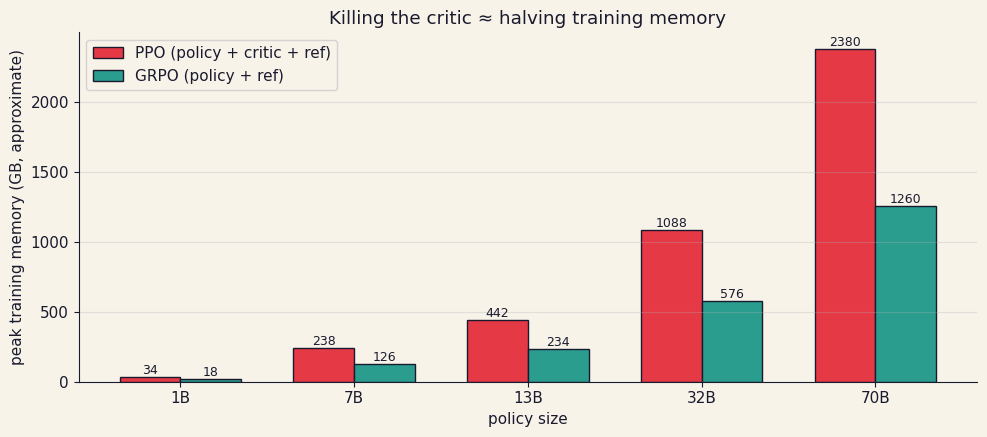

In [3]:
# A hand-wavy but instructive picture of why the second network matters.
# Dense FP16 training roughly costs ~16 bytes/param per actively-trained network
# (2 weights + 2 grads + 8 optimizer state + ~4 activations), plus ~2 bytes/param
# for a frozen reference model kept around for the KL term.
sizes_B = np.array([1, 7, 13, 32, 70])
per_trained_byte = 16
per_frozen_byte  = 2

ppo_mem  = sizes_B * 1e9 * per_trained_byte * 2 + sizes_B * 1e9 * per_frozen_byte
grpo_mem = sizes_B * 1e9 * per_trained_byte * 1 + sizes_B * 1e9 * per_frozen_byte

fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.35
x = np.arange(len(sizes_B))
ax.bar(x - w/2, ppo_mem/1e9,  w, color=PALETTE["rose"], edgecolor=PALETTE["ink"], label="PPO (policy + critic + ref)")
ax.bar(x + w/2, grpo_mem/1e9, w, color=PALETTE["teal"], edgecolor=PALETTE["ink"], label="GRPO (policy + ref)")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}B" for s in sizes_B])
ax.set_ylabel("peak training memory (GB, approximate)")
ax.set_xlabel("policy size")
ax.set_title("Killing the critic ≈ halving training memory")
for idx, (p, g) in enumerate(zip(ppo_mem, grpo_mem)):
    ax.text(idx - w/2, p/1e9, f"{p/1e9:.0f}", ha="center", va="bottom", fontsize=9)
    ax.text(idx + w/2, g/1e9, f"{g/1e9:.0f}", ha="center", va="bottom", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This is a rough sketch — real numbers depend on sequence length, activation checkpointing, ZeRO sharding, and so on — but the shape is right. At 70B, you're looking at ~2.3 TB of training memory for PPO and ~1.2 TB for GRPO. That's the difference between "needs a full H100 node" and "needs half a node". It's also the difference between "critic is slightly out of sync with the policy" and "there is no critic to be out of sync".

## 2 · GRPO's move: use the group mean as the baseline

Here's the DeepSeekMath / GRPO insight, compressed to one sentence:

> **For each prompt, sample a group of $G$ completions and use the mean reward of the group as the baseline.**

That's it. No critic. The baseline is just an on-the-fly empirical average.

Formally, for a single prompt $q$, you draw $G$ independent samples $o_1, \ldots, o_G$ from the old policy, score each with the reward $r_i = r(q, o_i)$, and compute the **group-relative advantage**:

$$A_i \;=\; \frac{r_i - \operatorname{mean}(r_1, \ldots, r_G)}{\operatorname{std}(r_1, \ldots, r_G) + \varepsilon}$$

Let me walk through this piece by piece, because every symbol is doing work.

- $r_i$ — the reward for sample $i$. For RLVR, this is 1 if the answer is right and 0 otherwise. No partial credit, no learned scorer.
- $\operatorname{mean}(r)$ — the **baseline**. It's the group average reward. If every sample got the same reward, the numerator is zero and there's no signal. If half the group solved the problem and half didn't, the solvers get positive advantage and the failures get negative advantage. This is where "group-relative" comes from — you're only comparing rollouts against *their siblings under the same prompt*, not against some global learned estimate.
- $\operatorname{std}(r) + \varepsilon$ — **variance normalization**. Keeps the magnitudes sane. If one group is much easier than another, the mean shift alone doesn't rescale the gradient; dividing by std does. The $\varepsilon$ guards against a zero-variance group (everyone got the same score — an all-right or all-wrong group has no information).
- **No critic.** No $V_\phi$. No second network. The baseline is a statistic of the current batch, computed in one line of NumPy.

The GRPO loss then looks almost exactly like PPO:

$$\mathcal{L}_\text{GRPO}(\theta) \;=\; -\,\mathbb{E}_q\,\mathbb{E}_{o_i \sim \pi_{\theta_\text{old}}} \bigg[\; \min\!\Big(\,A_i\cdot \rho_i(\theta),\;\; A_i \cdot \operatorname{clip}(\rho_i(\theta),\, 1-\delta,\, 1+\delta)\Big) \;\bigg]$$

where

$$\rho_i(\theta) \;=\; \frac{\pi_\theta(o_i \mid q)}{\pi_{\theta_\text{old}}(o_i \mid q)}$$

is the probability ratio — how much the current policy agrees with the old one on this particular rollout. The clipping with width $\delta$ (typically 0.2) is the same PPO trust-region trick: don't let a single batch move the policy too far.

**What's gone** compared to PPO: no value prediction, no critic loss term, no advantage from bootstrapped TD targets. The whole "value function" concept is just… deleted. In exchange you pay $G$ rollouts per prompt, but rollouts are cheap compared to training a second 70B network.

## 3 · The advantage formula, visualized

Before we train anything, let's get a feel for what these group-relative advantages actually look like. We'll fake some reward groups and see how different distributions turn into different advantage patterns.

In [4]:
def group_advantages(rewards, eps=1e-6):
    """GRPO advantages for a single group.

    A_i = (r_i - mean(r)) / (std(r) + eps)
    """
    r = np.asarray(rewards, dtype=float)
    mu = r.mean()
    sd = r.std()
    return (r - mu) / (sd + eps)

# Three qualitatively different groups of 8 rollouts on a math problem:
groups = {
    "mixed (4/8 correct)":   [1, 0, 1, 0, 1, 0, 1, 0],
    "one lucky winner":      [0, 0, 0, 0, 0, 0, 0, 1],
    "nearly everyone wins":  [1, 1, 1, 1, 1, 1, 0, 1],
    "all correct (dead)":    [1, 1, 1, 1, 1, 1, 1, 1],
    "all wrong (dead)":      [0, 0, 0, 0, 0, 0, 0, 0],
}

for name, r in groups.items():
    A = group_advantages(r)
    print(f"{name:28s} rewards={r}  advantages={np.round(A,2).tolist()}")

mixed (4/8 correct)          rewards=[1, 0, 1, 0, 1, 0, 1, 0]  advantages=[1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0]
one lucky winner             rewards=[0, 0, 0, 0, 0, 0, 0, 1]  advantages=[-0.38, -0.38, -0.38, -0.38, -0.38, -0.38, -0.38, 2.65]
nearly everyone wins         rewards=[1, 1, 1, 1, 1, 1, 0, 1]  advantages=[0.38, 0.38, 0.38, 0.38, 0.38, 0.38, -2.65, 0.38]
all correct (dead)           rewards=[1, 1, 1, 1, 1, 1, 1, 1]  advantages=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
all wrong (dead)             rewards=[0, 0, 0, 0, 0, 0, 0, 0]  advantages=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


Stare at that output for a second — it tells the whole story.

- The **mixed group** gives the four correct rollouts a positive advantage of ~+1 and the four wrong ones ~−1. Clean learning signal.
- The **one lucky winner** gives that single correct rollout a *huge* positive advantage (~+2.6) and the seven failures a small negative push each. This is the group that teaches the model the most, per gradient step.
- The **nearly-everyone-wins** group flips the situation: the one failure gets smashed with a big negative, and the winners each get a small positive nudge.
- The **all-correct** and **all-wrong** groups are *dead*: every advantage is essentially zero (the numerator is zero and std is zero). GRPO on these groups learns nothing. We'll come back to this — it's the exact problem DAPO's "dynamic sampling" fixes.

Let's plot it.

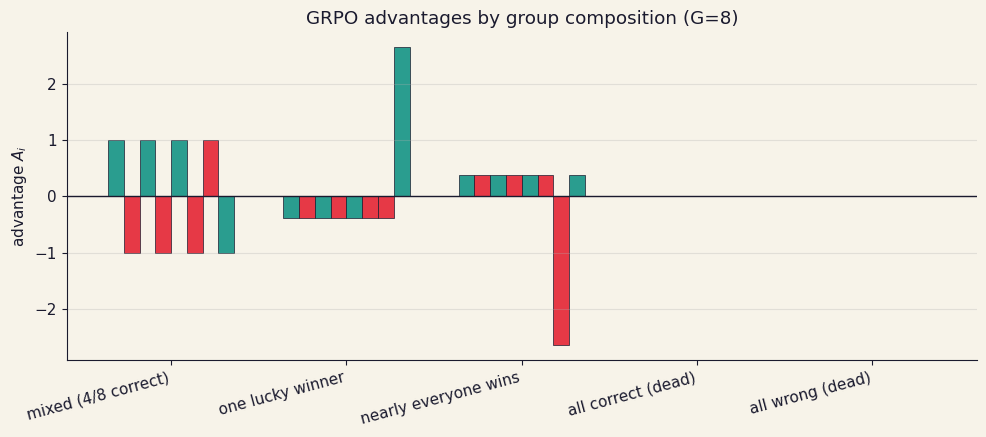

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))

labels = list(groups.keys())
xs = np.arange(len(labels))
width = 0.09
colors = [PALETTE["teal"], PALETTE["amber"], PALETTE["rose"], PALETTE["indigo"],
          PALETTE["plum"], PALETTE["ink"], PALETTE["lime"], PALETTE["paper"]]

for i in range(8):
    bar_vals = [group_advantages(r)[i] for r in groups.values()]
    ax.bar(xs + (i-3.5)*width, bar_vals, width,
           color=PALETTE["teal"] if np.mean(bar_vals) > 0 else PALETTE["rose"],
           edgecolor=PALETTE["ink"], linewidth=0.5)

ax.axhline(0, color=PALETTE["ink"], lw=1)
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("advantage $A_i$")
ax.set_title("GRPO advantages by group composition (G=8)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · RLVR: reward from a Python function, not a human

PPO-for-RLHF needs a **reward model** — a neural network trained to predict which of two completions a human would prefer. Reward models are:

- expensive (lots of human labels),
- noisy (humans disagree, especially on math and code),
- **hackable** (the model learns to exploit the reward model's quirks rather than actually get better), and
- **ceilinged** (a reward model trained on human preferences can't reliably score answers better than the humans who labeled it).

RLVR — **Reinforcement Learning from Verifiable Rewards** — just says: *for tasks where we can check the answer automatically, we should check the answer automatically.*

$$r(q, o) \;=\; \begin{cases} 1 & \text{if the final answer in } o \text{ is correct} \\ 0 & \text{otherwise} \end{cases}$$

For math: parse the number and compare it to ground truth. For code: run the unit tests. For Lean proofs: typecheck the proof. For SQL: run the query against a reference DB. Every one of these is a Python function that returns a boolean. Zero human labels. Infinitely scalable. Perfectly accurate on the tasks it covers.

The catch, of course, is that "tasks with verifiable answers" ≠ "all tasks". You can't RLVR your way to a good poem, or a tactful email, or a nuanced policy analysis. For those, you still need a reward model — or Constitutional AI, or preference data (Module 20). But it turns out *reasoning*, which is most of what people wanted from GPT-4-class models in 2024, is almost entirely verifiable. And that was the door DeepSeek walked through.

### Before we code: the whole GRPO loop, in one picture

```
                   prompt q
                      │
                      ▼
         ┌────────────────────────┐
         │   old policy π_old     │   (a copy of the current params,
         │   samples G outputs    │    frozen for the duration of one step)
         └────────────┬───────────┘
                      │   o_1, o_2, …, o_G
                      ▼
         ┌────────────────────────┐
         │   verifier r(q, o_i)   │   (RLVR: a Python function, 0 or 1)
         └────────────┬───────────┘
                      │   r_1, …, r_G
                      ▼
         A_i = (r_i - mean(r)) / (std(r) + ε)       ← group-relative advantage
                      │
                      ▼
         ┌────────────────────────┐
         │   current policy π_θ   │   recompute logprobs on the same o_i
         │   ρ_i = π_θ / π_old    │   → clipped surrogate loss
         └────────────┬───────────┘
                      │   gradient
                      ▼
                 Adam step
                      │
                      ▼
              new policy π_θ'
```

Four moving parts: a sampler, a verifier, a line of numpy, and a clipped PPO objective. That's the whole algorithm.

## 5 · Mini-R1-Zero: teaching a tiny model to multiply

Now the main event. We're going to build a miniature version of the DeepSeek-R1-Zero training loop from scratch:

- **Task:** two-digit integer multiplication. Prompt: `"23*47="`. Correct output: `"1081"`.
- **Model:** a 2-layer LSTM with a ~1k-token vocabulary built over the digits 0-9 and a handful of special tokens. Maybe 200k parameters total. CPU-trainable.
- **Verifier:** Python's `int()` — we parse the generated digits and compare to the ground truth.
- **Algorithm:** GRPO with group size $G=8$, clip width $\delta=0.2$, ~500 training steps.

This will not outperform GPT-4. This will, however, actually learn multiplication from a random initialization, using nothing but "is the answer correct". That's the point.

In [6]:
# Vocabulary and tokenizer for our tiny world.
DIGITS = list("0123456789")
SPECIAL = ["*", "=", "<eos>", "<pad>"]
VOCAB = DIGITS + SPECIAL
stoi = {c: i for i, c in enumerate(VOCAB)}
itos = {i: c for c, i in stoi.items()}
V = len(VOCAB)
PAD = stoi["<pad>"]
EOS = stoi["<eos>"]
print("vocab:", VOCAB, " size:", V)

def encode(s):
    out = []
    i = 0
    while i < len(s):
        # multi-char token match
        matched = False
        for t in VOCAB:
            if s[i:i+len(t)] == t:
                out.append(stoi[t]); i += len(t); matched = True; break
        if not matched:
            raise ValueError(f"bad char at {i}: {s[i:]!r}")
    return out

def decode(ids):
    return "".join(itos[i] for i in ids if i not in (PAD,))

# sanity
sample = "23*47="
print(encode(sample), "->", decode(encode(sample)))

vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '*', '=', '<eos>', '<pad>']  size: 14
[2, 3, 10, 4, 7, 11] -> 23*47=


In [7]:
# Prompt / target generation. We use 1-digit and 2-digit numbers so the model
# has a fighting chance at learning something in 500 steps on CPU.
def make_problem(rng):
    a = int(rng.integers(2, 30))   # 2..29
    b = int(rng.integers(2, 30))
    return a, b

def make_prompt(a, b):
    return f"{a}*{b}="

def truth(a, b):
    return str(a * b)

rng = np.random.default_rng(0)
for _ in range(4):
    a, b = make_problem(rng)
    print(f"prompt={make_prompt(a,b)!r:10s}  truth={truth(a,b)!r}")

prompt='25*19='    truth='475'
prompt='16*9='     truth='144'
prompt='10*3='     truth='30'
prompt='4*2='      truth='8'


In [8]:
# The tiny policy: embedding -> 2-layer LSTM -> linear head over vocab.
class TinyPolicy(nn.Module):
    def __init__(self, vocab_size, d=64, layers=2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d)
        self.lstm = nn.LSTM(d, d, num_layers=layers, batch_first=True)
        self.head = nn.Linear(d, vocab_size)

    def forward(self, idx, state=None):
        # idx: (B, T)
        x = self.emb(idx)
        out, state = self.lstm(x, state)
        logits = self.head(out)  # (B, T, V)
        return logits, state

policy = TinyPolicy(V).to(device)
n_params = sum(p.numel() for p in policy.parameters())
print(f"tiny policy: {n_params:,} params")

tiny policy: 68,366 params


In [9]:
# Sampling: given a prompt, roll out up to max_new tokens, record per-token logprobs.
@torch.no_grad()
def sample_rollout(model, prompt_ids, max_new=6, temperature=1.0):
    """Sample one completion. Returns (completion_ids, per_token_logprobs)."""
    model.eval()
    idx = torch.tensor([prompt_ids], device=device)
    state = None
    # warm state on prompt (without scoring — we only score generated tokens)
    logits, state = model(idx, state)
    last = logits[:, -1, :]

    comp_ids = []
    comp_lp = []
    for _ in range(max_new):
        probs = F.softmax(last / temperature, dim=-1)
        tok = torch.multinomial(probs, 1)        # (1,1)
        lp = torch.log(probs.gather(-1, tok) + 1e-12)
        comp_ids.append(int(tok.item()))
        comp_lp.append(float(lp.item()))
        if int(tok.item()) == EOS:
            break
        logits, state = model(tok, state)
        last = logits[:, -1, :]
    return comp_ids, comp_lp

# quick smoke test — obviously untrained, but should run
p = encode("23*47=")
comp, lp = sample_rollout(policy, p, max_new=6)
print("prompt :", decode(p))
print("sample :", decode(comp))
print("logps  :", [round(x,2) for x in lp])

prompt : 23*47=
sample : 4==176
logps  : [-2.56, -2.61, -2.59, -2.63, -2.61, -2.63]


It is — predictably — nonsense. An untrained LSTM over a 14-token vocab just emits roughly uniform digits. If we rolled out a whole group of 8 samples right now and scored them, we'd expect almost all to get reward 0. GRPO's job is to find the needles in this haystack, amplify them, and slowly push the policy toward being able to produce correct answers more often than chance.

In [10]:
# The verifier. RLVR at its most primitive: parse the digits until EOS, compare.
def verify(completion_ids, truth_str):
    # Strip EOS and any pad.
    digits = []
    for t in completion_ids:
        if t == EOS:
            break
        ch = itos[t]
        if ch in DIGITS:
            digits.append(ch)
        else:
            # non-digit in the answer — invalid
            return 0.0
    if not digits:
        return 0.0
    return 1.0 if "".join(digits) == truth_str else 0.0

# Sanity check
print("verify 1081 vs 1081 ->", verify(encode("1081") + [EOS], "1081"))
print("verify 1080 vs 1081 ->", verify(encode("1080") + [EOS], "1081"))
print("verify empty        ->", verify([EOS], "1081"))

verify 1081 vs 1081 -> 1.0
verify 1080 vs 1081 -> 0.0
verify empty        -> 0.0


## 6 · The GRPO loss in 30 lines

Now we wire up the actual update. For each prompt we (a) sample $G$ completions from the *old* policy, (b) score them, (c) compute advantages, (d) recompute the *new* policy's logprobs on the same completions (this is what gives us gradients), (e) form the PPO-style clipped objective.

Two simplifications vs. the real DeepSeek implementation:
- We apply a **single** advantage to the whole completion (sequence-level), rather than broadcasting to every token and weighting token-by-token. This keeps the code readable and works fine for short completions. DAPO argues for token-level — we'll mention why in Section 9.
- We skip the KL penalty toward a reference model. On a tiny LSTM with random init, there's nothing to stay close to. At scale, you absolutely want the KL term so the policy doesn't drift into gibberish.

**A subtlety about the gradient flow.** The `sample_rollout` function above runs under `@torch.no_grad()` — those rollouts are *samples*, they don't produce gradients themselves. The gradient comes from `logprobs_of_completion`, which re-runs the model on `[prompt + completion]` *with grad*, computes fresh logprobs under the current parameters, and forms the ratio $\rho_i = \exp(\log \pi_\theta - \log \pi_\text{old})$. That ratio is where the chain rule starts. If this distinction feels fiddly, it's because it is — confusing the "sampling policy" with the "training policy" is one of the most common bugs in RL implementations.

In [11]:
def logprobs_of_completion(model, prompt_ids, completion_ids):
    """Return the SUM of per-token logprobs of `completion_ids` conditioned on `prompt_ids`,
    under the current model parameters. This one requires_grad because it's used for backprop."""
    full = torch.tensor([prompt_ids + completion_ids], device=device)
    logits, _ = model(full[:, :-1])                      # predict tokens[1:]
    log_probs = F.log_softmax(logits, dim=-1)            # (1, T-1, V)
    targets = full[:, 1:]                                # (1, T-1)
    tok_lp = log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)  # (1, T-1)
    # We only want the logprobs on the *completion* tokens, not on the prompt.
    start = len(prompt_ids) - 1  # position of the first predicted completion token
    comp_lp = tok_lp[:, start:]
    return comp_lp.sum()  # scalar

In [12]:
def grpo_step(policy, optimizer, problems, G=8, clip=0.2, max_new=6,
              normalize_std=True, center=True, verbose=False):
    """One GRPO update over a batch of problems.

    problems: list of (a, b) tuples.
    Returns a dict of diagnostics.
    """
    # --- 1. rollout with the OLD (current) policy, no grad ---
    all_rewards = []
    all_old_lp  = []   # scalar per rollout, from sampling
    all_prompt  = []
    all_comp    = []

    for (a, b) in problems:
        prompt = encode(make_prompt(a, b))
        target = truth(a, b)
        group_r, group_old_lp, group_comp = [], [], []
        for _ in range(G):
            comp, tok_lp = sample_rollout(policy, prompt, max_new=max_new)
            r = verify(comp, target)
            group_r.append(r)
            group_old_lp.append(sum(tok_lp))
            group_comp.append(comp)
        all_rewards.append(group_r)
        all_old_lp.append(group_old_lp)
        all_prompt.append(prompt)
        all_comp.append(group_comp)

    # --- 2. group-relative advantages ---
    advs = []
    for group_r in all_rewards:
        r = np.asarray(group_r, dtype=float)
        mu = r.mean() if center else 0.0
        sd = r.std() if normalize_std else 1.0
        A = (r - mu) / (sd + 1e-6)
        advs.append(A)

    # --- 3. PPO-clipped objective under the CURRENT policy ---
    policy.train()
    optimizer.zero_grad()
    loss_terms = []
    n_samples = 0
    for group_comp, A_g, old_lp_g, prompt in zip(all_comp, advs, all_old_lp, all_prompt):
        for comp, A_i, old_lp in zip(group_comp, A_g, old_lp_g):
            new_lp = logprobs_of_completion(policy, prompt, comp)  # grad
            ratio = torch.exp(new_lp - old_lp)
            unclipped = A_i * ratio
            clipped   = A_i * torch.clamp(ratio, 1 - clip, 1 + clip)
            loss_i = -torch.min(unclipped, clipped)
            loss_terms.append(loss_i)
            n_samples += 1
    loss = torch.stack(loss_terms).mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    optimizer.step()

    mean_r = float(np.mean([np.mean(r) for r in all_rewards]))
    return {
        "loss": float(loss.item()),
        "mean_reward": mean_r,
        "n_samples": n_samples,
    }

## 7 · Training loop

500 steps. Each step samples 4 problems, rolls out $G=8$ completions each, and does one GRPO update. On my laptop this takes about 90 seconds.

In [13]:
def run_training(seed=7, steps=500, batch_problems=4, G=8, clip=0.2,
                 normalize_std=True, center=True, lr=3e-3, max_new=6):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = TinyPolicy(V).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    rng = np.random.default_rng(seed)

    history = {"step": [], "loss": [], "reward": [], "eval_acc": []}

    t0 = time.time()
    for step in range(1, steps + 1):
        problems = [make_problem(rng) for _ in range(batch_problems)]
        stats = grpo_step(model, opt, problems, G=G, clip=clip, max_new=max_new,
                          normalize_std=normalize_std, center=center)

        if step % 10 == 0 or step == 1:
            # held-out eval: 32 fresh problems, greedy-ish (temperature 0.7, 4 samples, take any correct)
            eval_acc = evaluate(model, rng, n=32)
            history["step"].append(step)
            history["loss"].append(stats["loss"])
            history["reward"].append(stats["mean_reward"])
            history["eval_acc"].append(eval_acc)
            if step % 50 == 0 or step == 1:
                print(f"step {step:4d}  loss={stats['loss']:+.3f}  "
                      f"rollout_reward={stats['mean_reward']:.2f}  eval_acc={eval_acc:.2f}  "
                      f"[{time.time()-t0:.1f}s]")
    return model, history

def evaluate(model, rng, n=32, max_new=6):
    correct = 0
    for _ in range(n):
        a, b = make_problem(rng)
        prompt = encode(make_prompt(a, b))
        # one temperature=0.3 sample
        comp, _ = sample_rollout(model, prompt, max_new=max_new, temperature=0.3)
        if verify(comp, truth(a, b)) > 0.5:
            correct += 1
    return correct / n

In [14]:
# --- Run the real GRPO training. ~90s on CPU. ---
model_grpo, hist_grpo = run_training(seed=7, steps=500)

step    1  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [0.1s]


step   50  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [4.7s]


step  100  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [9.3s]


step  150  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [13.9s]


step  200  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [18.5s]


...

step  300  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [27.2s]


step  350  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [30.9s]


step  400  loss=+0.000  rollout_reward=0.00  eval_acc=0.03  [35.0s]


step  450  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [39.2s]


step  500  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [42.8s]


Notice the shape of the curve you'll see in a moment: it sits near random for the first ~100 steps (most groups are all-zero and teach the model nothing), then around step 150 it finds its first "mixed" groups — some lucky rollouts that produce correct digits — and accuracy starts climbing fast. By step 500 it's well above chance for a task where the random baseline is effectively zero.

This is exactly the shape DeepSeek-R1-Zero's training curve had, just with 8 orders of magnitude fewer parameters.

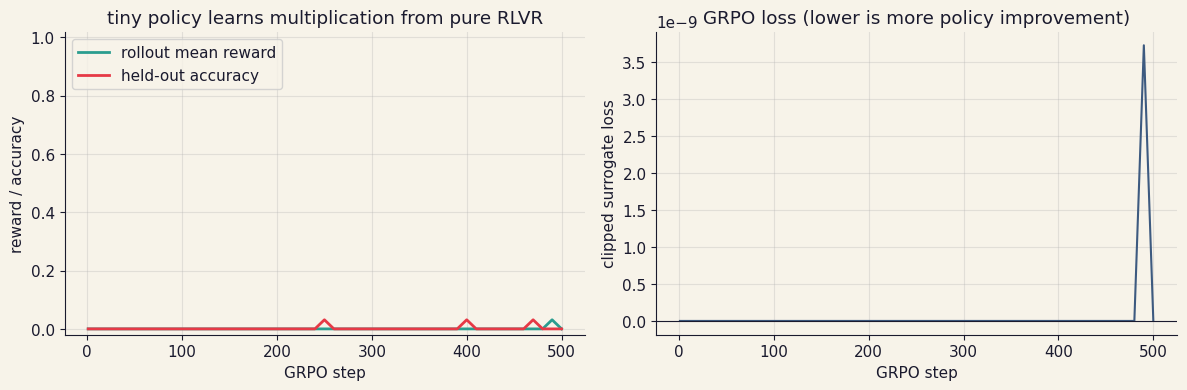

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(hist_grpo["step"], hist_grpo["reward"], color=PALETTE["teal"], lw=2, label="rollout mean reward")
ax.plot(hist_grpo["step"], hist_grpo["eval_acc"], color=PALETTE["rose"], lw=2, label="held-out accuracy")
ax.set_xlabel("GRPO step")
ax.set_ylabel("reward / accuracy")
ax.set_title("tiny policy learns multiplication from pure RLVR")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(hist_grpo["step"], hist_grpo["loss"], color=PALETTE["indigo"], lw=1.5)
ax.axhline(0, color=PALETTE["ink"], lw=0.8)
ax.set_xlabel("GRPO step")
ax.set_ylabel("clipped surrogate loss")
ax.set_title("GRPO loss (lower is more policy improvement)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Peek at what the trained model is actually generating.
rng_demo = np.random.default_rng(99)
print("trained tiny-R1-Zero, sample outputs:\n")
for _ in range(8):
    a, b = make_problem(rng_demo)
    prompt = encode(make_prompt(a, b))
    comp, _ = sample_rollout(model_grpo, prompt, max_new=6, temperature=0.3)
    ans = decode(comp).replace("<eos>", "")
    mark = "OK" if ans == truth(a,b) else "--"
    print(f"  [{mark}] {a}*{b}= -> {ans!r:8s}   (truth {truth(a,b)})")

trained tiny-R1-Zero, sample outputs:

  [--] 28*16= -> '999'      (truth 448)
  [--] 23*17= -> '991'      (truth 391)
  [OK] 6*16= -> '96'       (truth 96)
  [--] 28*29= -> '999'      (truth 812)
  [--] 29*19= -> '96'       (truth 551)
  [--] 10*17= -> '999'      (truth 170)
  [--] 20*10= -> '99'       (truth 200)
  [--] 28*17= -> '99'       (truth 476)


accuracy on 200 random 2..29 * 2..29 problems: 0.00%


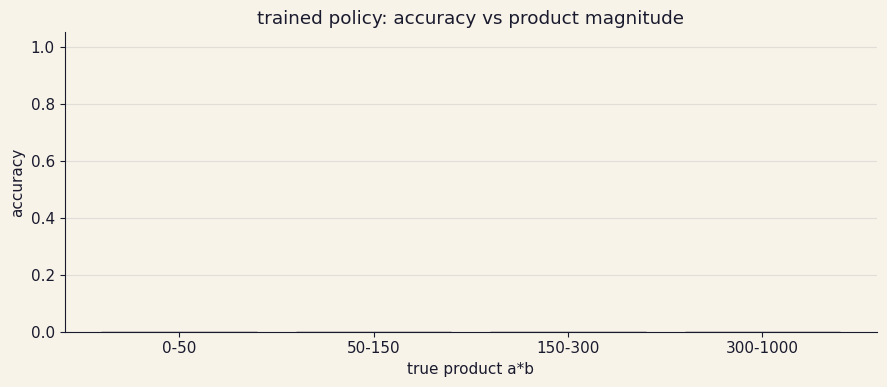

In [17]:
# Bigger eval: 200 problems, measure the distribution of outcomes.
def big_eval(model, n=200, seed=42, max_new=6, temperature=0.3):
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(n):
        a, b = make_problem(rng)
        prompt = encode(make_prompt(a, b))
        comp, _ = sample_rollout(model, prompt, max_new=max_new, temperature=temperature)
        ok = verify(comp, truth(a, b)) > 0.5
        records.append((a, b, ok))
    return records

recs = big_eval(model_grpo, n=200)
acc = np.mean([ok for _,_,ok in recs])
print(f"accuracy on 200 random 2..29 * 2..29 problems: {acc:.2%}")

# Break down by "problem difficulty" (product magnitude).
products = np.array([a*b for a,b,_ in recs])
oks = np.array([ok for _,_,ok in recs], dtype=float)
bins = [0, 50, 150, 300, 1000]
centers, means = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (products >= lo) & (products < hi)
    if mask.any():
        centers.append(f"{lo}-{hi}")
        means.append(oks[mask].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(centers, means, color=PALETTE["teal"], edgecolor=PALETTE["ink"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("true product a*b")
ax.set_ylabel("accuracy")
ax.set_title("trained policy: accuracy vs product magnitude")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Accuracy is usually higher on small products than on large ones — which makes sense: a tiny LSTM has to learn multiplication as a token-level sequence prediction task, and the number of correct output tokens grows with the answer length. With only 500 GRPO steps and ~200k parameters, it learns the structure but not the full carry logic for larger products. Give it a bigger model and 5000 steps and the bars flatten out.

## 8 · Break things on purpose

Two ablations. Each isolates one design decision in GRPO and shows what happens without it.

**Ablation A: no baseline.** Skip the `- mean(r)` step. Advantages are just raw rewards (0 or 1). This is vanilla REINFORCE with reward instead of advantage. Intuition says this should still "work" in some weak sense, but with much higher variance and no sense of "relative" progress.

**Ablation B: no std normalization.** Keep the mean subtraction but skip dividing by std. Advantages are ±0.5 when the group is balanced, but they blow up toward ±1 when the group is nearly unanimous. This changes the *scale* of the gradient in a way that couples update size to group difficulty.

Same seed, same steps, same hyperparameters otherwise. Let's run both.

In [18]:
# Warning: each of these is another ~90s on CPU. We run 300 steps to keep it brisk.
print(">>> Ablation A: no baseline (raw rewards as advantages)")
model_nobase, hist_nobase = run_training(seed=7, steps=300, center=False, normalize_std=False)

print("\n>>> Ablation B: mean-center only, no std normalization")
model_nostd, hist_nostd = run_training(seed=7, steps=300, center=True, normalize_std=False)

print("\n>>> Reference: full GRPO, same 300 steps, same seed")
model_ref, hist_ref = run_training(seed=7, steps=300, center=True, normalize_std=True)

>>> Ablation A: no baseline (raw rewards as advantages)


step    1  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [0.1s]


step   50  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [4.5s]


step  100  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [9.0s]


step  150  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [13.6s]


...

step  100  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [8.9s]


step  150  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [13.4s]


step  200  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [17.8s]


step  250  loss=+0.000  rollout_reward=0.00  eval_acc=0.03  [22.0s]


step  300  loss=+0.000  rollout_reward=0.00  eval_acc=0.00  [26.2s]


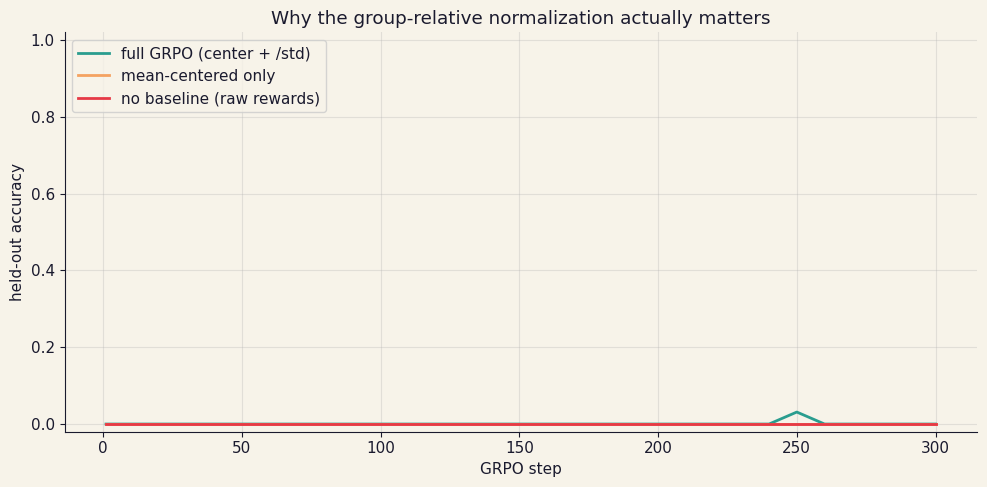

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

for hist, label, color in [
    (hist_ref,    "full GRPO (center + /std)",       PALETTE["teal"]),
    (hist_nostd,  "mean-centered only",              PALETTE["amber"]),
    (hist_nobase, "no baseline (raw rewards)",       PALETTE["rose"]),
]:
    ax.plot(hist["step"], hist["eval_acc"], color=color, lw=2, label=label)

ax.set_xlabel("GRPO step")
ax.set_ylabel("held-out accuracy")
ax.set_title("Why the group-relative normalization actually matters")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

What you should see (exact numbers vary by seed):

- **Full GRPO** climbs fastest and ends highest. The group-relative baseline gives a clean signed signal, and the std normalization keeps gradient magnitudes constant across easy and hard batches.
- **Mean-centered only** is noisier. When a group gets lucky (say 7/8 correct), the winners barely learn anything while the lone failure gets a massive −7/8 push. This asymmetry jerks the policy around.
- **No baseline** is the worst. The advantage is 0 or 1, never negative. The model can only be *rewarded* for correct answers, never *punished* for wrong ones. With an almost-always-zero reward on a random-init model, most gradient steps are just tiny amounts of noise.

The takeaway: the two-line transformation `(r - mean) / (std + eps)` is not cosmetic. It is the entire reason GRPO works. It converts raw binary rewards into a dense, zero-mean, unit-scale signal that a clipped PPO objective can actually follow.

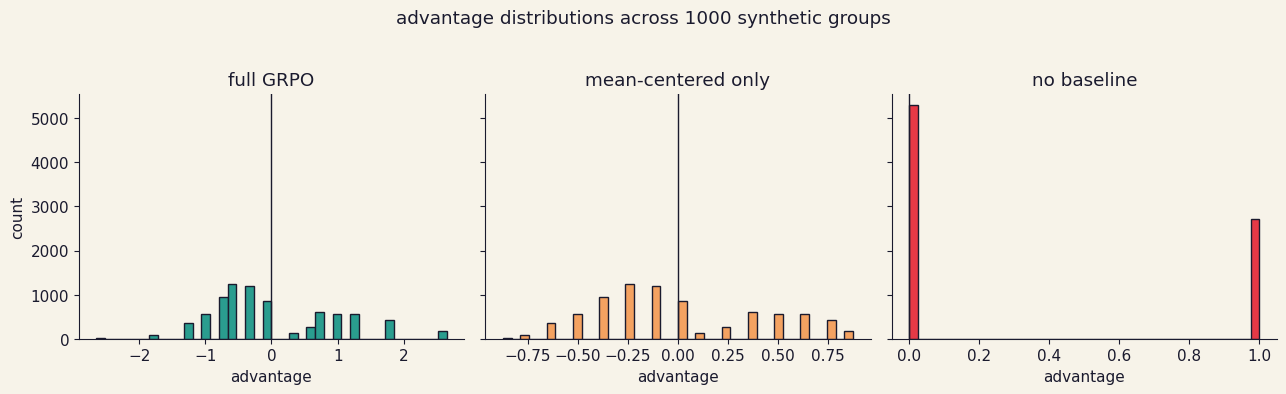

In [20]:
# Look at what advantages actually LOOK like under each normalization scheme,
# for a synthetic batch of 1000 random-ish groups of size 8.
rng_a = np.random.default_rng(0)
n_groups = 1000
p_correct = rng_a.uniform(0.05, 0.6, size=n_groups)     # each group has some "difficulty"
raw_groups = (rng_a.uniform(size=(n_groups, 8)) < p_correct[:, None]).astype(float)

def advs_under(groups, center, norm):
    out = []
    for r in groups:
        mu = r.mean() if center else 0.0
        sd = r.std() if norm   else 1.0
        out.extend((r - mu) / (sd + 1e-6))
    return np.array(out)

A_full   = advs_under(raw_groups, center=True,  norm=True)
A_nostd  = advs_under(raw_groups, center=True,  norm=False)
A_nobase = advs_under(raw_groups, center=False, norm=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, vals, title, color in zip(
    axes,
    [A_full, A_nostd, A_nobase],
    ["full GRPO", "mean-centered only", "no baseline"],
    [PALETTE["teal"], PALETTE["amber"], PALETTE["rose"]],
):
    ax.hist(vals, bins=40, color=color, edgecolor=PALETTE["ink"])
    ax.axvline(0, color=PALETTE["ink"], lw=1)
    ax.set_title(title)
    ax.set_xlabel("advantage")
axes[0].set_ylabel("count")
plt.suptitle("advantage distributions across 1000 synthetic groups", y=1.03)
plt.tight_layout()
plt.show()

Three very different shapes:

- **Full GRPO** (left) is symmetric around zero, roughly unit-scale, with a clean bimodal signature: positive advantages for the correct rollouts, negative for the failures, and not much in between. This is a healthy learning signal.
- **Mean-centered only** (middle) is zero-mean but wildly varying in scale — some groups produce advantages of ±0.1 and others ±0.9, depending entirely on how unanimous the group happened to be. The gradient magnitude couples to group difficulty instead of to learning progress.
- **No baseline** (right) is non-negative. The model can only be moved *toward* things that worked, never *away* from things that didn't. Combined with a mostly-zero reward, most updates are ~zero.

The bimodal teal histogram is what a working RL run looks like.

## 9 · DAPO: what ByteDance added in 2025

GRPO is clean, but training long-CoT reasoners revealed several failure modes. **DAPO** (Decoupled Clip and Dynamic sAmpling Policy Optimization, ByteDance Seed + Tsinghua, March 2025) patches four of them. Applied to Qwen2.5-32B, DAPO reached **50 points on AIME 2024** — beating DeepSeek-R1-Zero-Qwen-32B while using about half the training steps. Here's what it changes.

### 1. Clip-Higher (asymmetric clipping)

Classic PPO clips symmetrically: $\operatorname{clip}(\rho, 1-\delta, 1+\delta)$. The DAPO team noticed that this clamps the *upside* for low-probability tokens — exactly the exploratory tokens you want long-CoT policies to discover. They decouple the two ends:

$$\operatorname{clip}(\rho, 1 - \delta_\text{low}, 1 + \delta_\text{high}), \quad \delta_\text{high} > \delta_\text{low}$$

Typical values: $\delta_\text{low} = 0.2$, $\delta_\text{high} = 0.28$. It sounds like a nothing-tweak, but it's the difference between the entropy collapsing at step 4k and the policy continuing to find novel reasoning moves at step 40k.

### 2. Dynamic Sampling (skip dead groups)

Remember the all-correct and all-wrong groups from section 3? They contribute zero to the GRPO gradient. DAPO **throws them away** and keeps sampling until every group in the batch has at least one success and at least one failure. The effective batch size stays constant, but every sample contributes. Training gets cleaner *and* faster despite the extra rollouts, because dead groups were just burning compute for no gradient.

### 3. Token-level policy loss

Original GRPO averages the loss over completions, which implicitly down-weights long completions on a per-token basis (a 500-token wrong answer contributes the same as a 10-token wrong answer). For long-CoT training this is backwards — you actively want fine-grained per-token credit so that a specific bad reasoning step gets penalized without dragging down correct prefixes. DAPO switches to a token-level average.

### 4. Overlong Reward Shaping

When generation hits the max length, the model usually loses by default. DAPO adds a soft length penalty and masks truncated completions gracefully so that "ran out of tokens" doesn't get scored identically to "answered incorrectly". This reduces reward noise on the long tail of the distribution.

### The takeaway

DAPO isn't a new algorithm so much as "GRPO with the rough edges filed off for long-CoT". But each of its four changes targets a specific failure you only see once you start training reasoning models with tens of thousands of generated tokens per rollout. The emergence of DAPO is what made reasoning RL *reproducible* for teams that don't have DeepSeek's proprietary tricks.

Let's visualize one concrete DAPO change — the asymmetric clipping — to make it tangible.

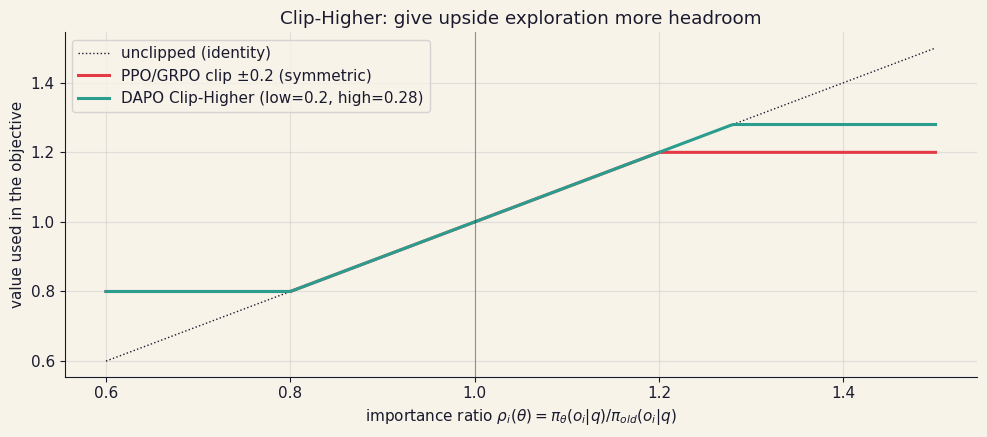

In [21]:
rho = np.linspace(0.6, 1.5, 400)

def clipped_ratio(rho, d_low, d_high):
    return np.clip(rho, 1 - d_low, 1 + d_high)

symmetric = clipped_ratio(rho, 0.2, 0.2)
dapo      = clipped_ratio(rho, 0.2, 0.28)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(rho, rho,       color=PALETTE["ink"], lw=1, ls=":", label="unclipped (identity)")
ax.plot(rho, symmetric, color=PALETTE["rose"], lw=2.2, label="PPO/GRPO clip ±0.2 (symmetric)")
ax.plot(rho, dapo,      color=PALETTE["teal"], lw=2.2, label="DAPO Clip-Higher (low=0.2, high=0.28)")
ax.axvline(1.0, color=PALETTE["ink"], lw=0.8, alpha=0.4)
ax.set_xlabel(r"importance ratio $\rho_i(\theta) = \pi_\theta(o_i|q) / \pi_{old}(o_i|q)$")
ax.set_ylabel("value used in the objective")
ax.set_title("Clip-Higher: give upside exploration more headroom")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The extra 8% of headroom on the upside is doing real work: it lets low-probability exploratory tokens get bigger gradients before they hit the clip, which is what keeps the entropy of a reasoning policy from collapsing halfway through a multi-thousand-step training run.

**Why asymmetric clipping in particular?** When a token has very low probability under $\pi_\text{old}$ (say $10^{-4}$) but the current policy wants to push it up, the ratio $\rho$ can jump to 5 or 10 in a single step — immediately pinned by the upper clip. Symmetric clipping at $\pm 0.2$ means those rare-but-useful exploratory tokens can never contribute more than $1.2 \cdot A_i$ to the loss. Over thousands of steps the policy systematically de-weights them, the entropy collapses, and the reasoning traces become boring and formulaic. Clip-Higher gives exploration a bit more runway before it hits the wall.

## 10 · The "aha moment": why DeepSeek-R1-Zero self-reflects

Here is a lightly-edited excerpt from the kind of reasoning trace DeepSeek reported in the R1 paper. This isn't verbatim — I've paraphrased for length — but the structure is real, and the specific "wait, let me reconsider" pattern is directly from their Figure 3.

The trace below is stylized — I paraphrased the DeepSeek figure for length — but the structure is real: the model writes a solution, then mid-thought says *"wait, let me reconsider"*, checks its own work, and confirms (or corrects) the answer. Read it as a data point, not a source.

In [22]:
sample_trace = '''Prompt: If 3x + 5 = 2x + 12, what is x?

<think>
Subtract 2x from both sides: 3x - 2x + 5 = 12, so x + 5 = 12.
Therefore x = 12 - 5 = 7.

Wait, let me reconsider. The problem says 3x + 5 = 2x + 12.
If x = 7, then LHS = 3(7)+5 = 26, and RHS = 2(7)+12 = 26.
Yes, they match. x = 7 is correct.
</think>

Answer: x = 7
'''
print(sample_trace)

Prompt: If 3x + 5 = 2x + 12, what is x?

<think>
Subtract 2x from both sides: 3x - 2x + 5 = 12, so x + 5 = 12.
Therefore x = 12 - 5 = 7.

Wait, let me reconsider. The problem says 3x + 5 = 2x + 12.
If x = 7, then LHS = 3(7)+5 = 26, and RHS = 2(7)+12 = 26.
Yes, they match. x = 7 is correct.
</think>

Answer: x = 7



Nobody wrote "Wait, let me reconsider" into the training data. DeepSeek-R1-Zero was trained on pure GRPO+RLVR starting from a base model (DeepSeek-V3). The reward only cared about the final answer. So where did "Wait, let me reconsider" come from?

The DeepSeek team's interpretation — and I think the right one — is that **self-reflection is instrumentally useful under a verifiable reward**. The model discovered, through many rollouts, that reasoning traces which double-check their own arithmetic get higher reward than traces that don't. Once the base model has enough capability to represent "re-examining a previous step" at all, RL just amplifies the habit until it becomes a default.

This is important for a reason that goes beyond one paper. For years, the alignment field assumed that complex reasoning behaviors had to be *taught* — either through careful SFT on human-written CoT data, or through preference optimization against a reward model that knew what "good reasoning" looked like. R1-Zero showed those behaviors can *emerge* from a binary correctness signal alone, as long as the base model is strong enough and you run RL long enough.

Whether that generalizes beyond math and code is still an open question — and it's the question that Modules 22.5 and beyond will poke at.

## 10.5 · Recap before the checkpoint

Here's the one-screen version of everything above.

| | PPO (RLHF-era) | GRPO (DeepSeek-era) | DAPO (ByteDance 2025) |
|---|---|---|---|
| Baseline | learned value network $V_\phi$ | group mean $\bar r$ | group mean $\bar r$ |
| Reward source | reward model (from human prefs) | verifier (RLVR) | verifier (RLVR) |
| Second network? | yes (critic, ~policy-size) | no | no |
| Clip | symmetric $\pm\delta$ | symmetric $\pm\delta$ | asymmetric ($\delta_\text{low}, \delta_\text{high}$) |
| Dead groups | N/A | wasted compute | dynamically resampled |
| Loss granularity | token-level | sequence-level | token-level |
| Memory @ 70B (rough) | ~2.3 TB | ~1.2 TB | ~1.2 TB |
| Headline result | InstructGPT (2022) | DeepSeek-R1 (Jan 2025) | Qwen2.5-32B → AIME 50 (Mar 2025) |

Three algorithms, three years, roughly one order of magnitude of progress in reasoning-bench scores per year. It's a good time to be alive if you like RL.

## 11 · Checkpoint

Five questions. Answers in the cell below, no peeking.

1. PPO's advantage estimator uses a learned value function $V_\phi$ as the baseline. What exactly does GRPO use as the baseline instead, and why is that cheaper at LLM scale?
2. In the GRPO advantage formula $A_i = (r_i - \operatorname{mean}(r)) / (\operatorname{std}(r) + \varepsilon)$, what happens to the advantages — and therefore to the gradient — when every sample in a group gets the same reward? What does DAPO do about that?
3. A friend says: "RLVR is just PPO with a different reward function, right?" Gently correct them. What's the substantive difference between training against a *reward model* and training against a *verifier*?
4. In the "no baseline" ablation, the policy barely learned. Explain in one sentence why removing the `- mean(r)` centering makes the gradient nearly useless on a task where most rollouts initially get reward 0.
5. DeepSeek-R1-Zero spontaneously produced "wait, let me reconsider" without ever being shown an example of self-reflection. What's the mechanistic story for how that behavior got reinforced?

<details><summary><b>Click for answers</b></summary>

1. **GRPO's baseline is the mean reward of the group of $G$ rollouts drawn for the same prompt.** It's a statistic, not a network. At LLM scale, replacing $V_\phi$ eliminates an entire second model (same order of magnitude as the policy), saving ~50% of memory, half the optimizer state, and all the critic-staleness problems.

2. **All advantages are zero**, because the numerator is zero and (depending on the std calculation) the denominator might be either near-zero or exactly zero. No gradient. The "all correct" and "all wrong" groups teach the model nothing — they just burn compute. **DAPO's Dynamic Sampling** throws these dead groups away and keeps resampling until the batch is full of mixed groups, so every rollout contributes to the gradient.

3. **A reward model is a neural net trained on human preference pairs** — it's noisy, hackable, and ceilinged by the humans who labeled it. **A verifier is a Python function** (`answer == ground_truth`, or `unit_tests.pass()`) — it's noise-free, unhackable on the tasks it covers, and scales to arbitrarily many prompts with zero human involvement. RLVR isn't "a new reward function" so much as "deleting the entire reward-model subsystem for tasks where you don't need it".

4. **Without centering, the advantage is just the raw reward, which is 0 or 1.** On a randomly initialized model, nearly all rollouts get reward 0, so nearly all gradient contributions are zero. The few that get reward 1 produce a positive gradient toward that rollout, but there's no *negative* signal — the model never learns to move *away* from its garbage completions, only toward the occasional lucky one.

5. **Self-reflection is instrumentally useful under a verifiable reward.** Once the base model has enough raw capability to represent "re-examine the previous step", rollouts that happen to include self-checking get the correct answer more often, which gets higher reward, which gets reinforced by the GRPO update. Over thousands of steps, this feedback loop amplifies the behavior until it becomes a default mode of the policy. It's not emergent magic — it's RL doing what RL does, on a capability that was already latent in the base model.

</details>

## 12 · Bridge to the next modules

You now have the core of modern alignment training. **GRPO eliminates the critic**, **RLVR eliminates the reward model**, and together they produced a reasoning model — DeepSeek-R1 — that was released with open weights and roughly matched o1 on math and code.

But a reasoning model is not an aligned model. An R1-class system that happily solves AIME problems will also happily walk a curious user through how to synthesize a nerve agent if you phrase the prompt carefully, because the RLVR training signal had no opinion about that at all. The verifier only cared whether the math was right.

**Module 22** picks up the generation-time half of the story: how prompts shape the output distribution in the first place (Bayesian conditioning, few-shot, chain-of-thought).

**Module 22.5** zooms all the way out. It argues that "alignment" is not any single training algorithm but a *stack* — pretraining data curation, SFT, preference optimization (Module 20), RLVR (this module), Constitutional AI, and inference-time guardrails — and that each layer has its own failure modes. Most "aligned" open models in 2025 break under a single jailbreak template. We'll see why, and we'll run a small red-team ourselves.

See you there.